# 1. Import libraries 

In [36]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Date handling
from datetime import datetime

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

# Dimensionality Reduction (Optional for visualization)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Evaluation
from sklearn.metrics import silhouette_score

# 2. Importing the dataset¶

In [37]:
dataset = pd.read_csv("D:\STATA và PYTHON\LAB03\penguins.csv", encoding='ISO-8859-1')


# 3. Exploratory Data Analysis

In [38]:
#Examining the first 10 rows of the dataset.
dataset.head(10)

,ï»¿culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
5,39.3,20.6,190.0,3650.0,MALE
6,38.9,17.8,181.0,3625.0,FEMALE
7,39.2,19.6,195.0,4675.0,MALE
8,34.1,18.1,193.0,3475.0,NaN
9,42.0,20.2,5000.0,4250.0,MALE


In [39]:
#Inspecting the shape, or dimensions, of the dataset.
dataset.shape

(344, 5)

In [40]:
#Examining the data types of each column and counting the number of non-null values in those columns.
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ï»¿culmen_length_mm  342 non-null    float64
 1   culmen_depth_mm      342 non-null    float64
 2   flipper_length_mm    342 non-null    float64
 3   body_mass_g          342 non-null    float64
 4   sex                  335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [41]:
#Obtaining the statistical summary of the dataset.
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
ï»¿culmen_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.50,59.6
culmen_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.70,21.5
flipper_length_mm,342.0,214.014620,260.558057,-132.0,190.000,197.00,213.75,5000.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.00,6300.0


In [42]:
# Handling missing values
dataset.dropna(inplace=True)

dataset.isnull().sum()

ï»¿culmen_length_mm    0
culmen_depth_mm        0
flipper_length_mm      0
body_mass_g            0
sex                    0
dtype: int64

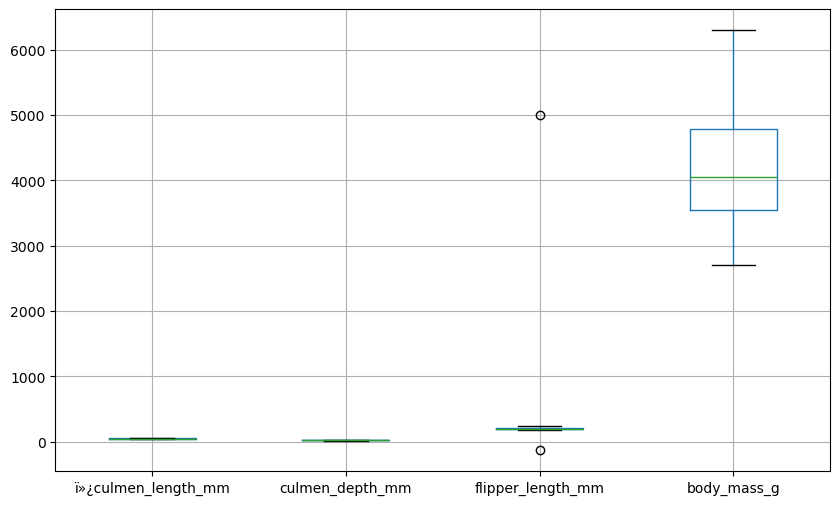

In [43]:
#Checking for outliers

plt.figure(figsize=(10, 6))
dataset.boxplot()
plt.show()

In [44]:
sum(dataset['flipper_length_mm'] > 4000)

1

In [45]:
#Filter out rows with incorrect or placeholder values in the 'sex' column
dataset = dataset.loc[dataset['sex'].isin(['MALE', 'FEMALE'])]

#Filter out outliers
dataset = dataset[(dataset['flipper_length_mm'].between(0, 4000))]

#Reset index
dataset.reset_index(drop=True, inplace=True)

dataset.describe()

,ï»¿culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,332.000000,332.000000,332.000000,332.000000
mean,44.021084,17.153012,200.975904,4206.475904
std,5.452462,1.960275,14.035971,806.361278
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.700000,17.300000,197.000000,4025.000000
75%,48.625000,18.700000,213.000000,4781.250000
max,59.600000,21.500000,231.000000,6300.000000


In [46]:
#Checking for any duplicates in the columns.
dataset.duplicated().sum()

np.int64(0)

# 4. Encoding categorical data

In [47]:
dataset = pd.get_dummies(dataset, drop_first=True)

dataset.head()

,ï»¿culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_MALE
0,39.1,18.7,181.0,3750.0,True
1,39.5,17.4,186.0,3800.0,False
2,40.3,18.0,195.0,3250.0,False
3,36.7,19.3,193.0,3450.0,False
4,39.3,20.6,190.0,3650.0,True


# 5. Feature Scaling

In [48]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()
scaled = Scaler.fit_transform(dataset)
dataset_scaled = pd.DataFrame(scaled, columns=dataset.columns)

print(dataset_scaled.head())

   ï»¿culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0            -0.903906         0.790360          -1.425342    -0.566948   
1            -0.830434         0.126187          -1.068577    -0.504847   
2            -0.683490         0.432728          -0.426399    -1.187953   
3            -1.344738         1.096901          -0.569105    -0.939551   
4            -0.867170         1.761074          -0.783164    -0.691149   

   sex_MALE  
0  0.993994  
1 -1.006042  
2 -1.006042  
3 -1.006042  
4  0.993994  


# 6. Principal Component Analysis (PCA)

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None)
pca_dataset = pca.fit(dataset_scaled)

pca_dataset.explained_variance_ratio_

array([0.56820593, 0.28153159, 0.09633697, 0.03399271, 0.01993278])

In [50]:
pca = PCA(n_components = 2)
pca_dataset = pca.fit_transform(dataset_scaled)

# 7. Hierarchical Clustering

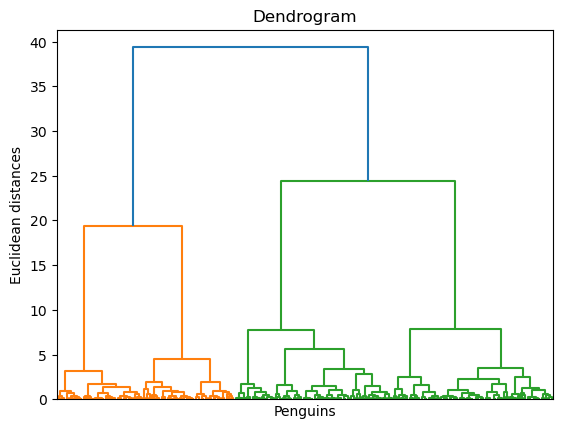

In [51]:
#Ward’s Method:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(pca_dataset, method = 'ward'),no_labels=True)
plt.title('Dendrogram')
plt.xlabel('Penguins')
plt.ylabel('Euclidean distances')
plt.show()

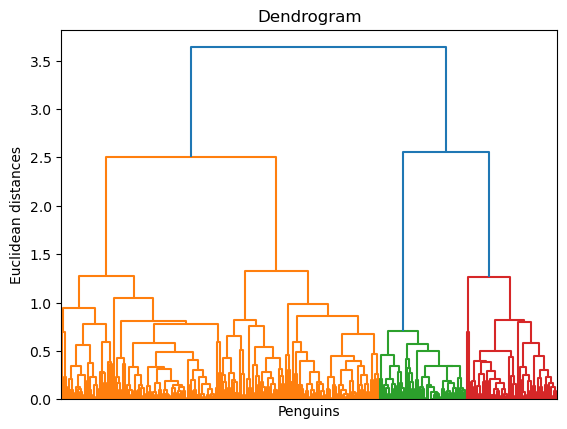

In [52]:
#Average Linkage Method:
dendrogram = sch.dendrogram(sch.linkage(pca_dataset, method = 'average'),no_labels=True)
plt.title('Dendrogram')
plt.xlabel('Penguins')
plt.ylabel('Euclidean distances')
plt.show()  

In [53]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 4, metric = 'euclidean', linkage = 'average')
y_hc = hc.fit_predict(pca_dataset)


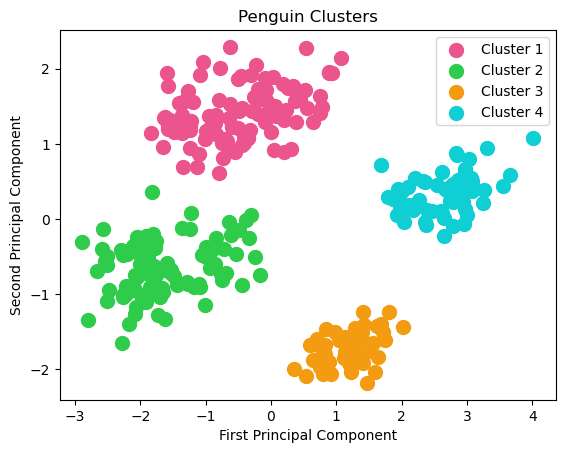

In [54]:
plt.scatter(pca_dataset[y_hc == 0, 0], pca_dataset[y_hc == 0, 1], s = 100, c = '#EB548C', label = 'Cluster 1')
plt.scatter(pca_dataset[y_hc == 1, 0], pca_dataset[y_hc == 1, 1], s = 100, c = '#2FCC4C', label = 'Cluster 2')
plt.scatter(pca_dataset[y_hc == 2, 0], pca_dataset[y_hc == 2, 1], s = 100, c = '#F39C12', label = 'Cluster 3')
plt.scatter(pca_dataset[y_hc == 3, 0], pca_dataset[y_hc == 3, 1], s = 100, c = '#0FCED4', label = 'Cluster 4')
plt.title('Penguin Clusters')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.legend()
plt.show()